In [1]:
import tensorflow as tf

import os
from pathlib import Path
import datetime
import numpy as np
import random


from IPython.display import display, clear_output
from tqdm.notebook import tqdm, trange

# from fid import get_frechet_inception_distance
import pandas as pd

from normalize import images_from_normalized
from data_generator import PreprocessedDataGenerator
from plot import plot_results, save_gif
from model import get_generator_model, get_discriminator_model
from loss import l1_loss, euclidean_distance, GeneratorLoss, DiscriminatorLoss, pairwise_loss
from splits import TRAIN_PATHS, TEST_PATHS

2023-10-19 20:55:27.477775: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-10-19 20:55:27.520488: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2023-10-19 20:55:27.520522: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2023-10-19 20:55:27.520550: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-10-19 20:55:27.528600: I tensorflow/core/platform/cpu_feature_g

In [2]:
tf.__version__

'2.14.0-rc1'

In [3]:
TRAIN = False
TEST = True
TEST_VIDEO = False
PLOT = False
SAVE_GIFS = True
TEST_DEFORMATIONS = False

COHERENCE_LOSS = l1_loss
TARGET_PREDICTED_LOSS = l1_loss
LANDMARKS_LOSS = pairwise_loss
LANDMARKS_COHERENCE_LOSS = pairwise_loss
INTERPOLATION_FRAMES_LOSS = l1_loss
INTERPOLATION_LANDMARKS_LOSS = None

# Dimensions
r = 256
IMG_WIDTH = r
IMG_HEIGHT = r
N_CHANNELS = 3

N_LANDMARKS = 68
BATCH_SIZE = 10
STEPS = 100000
STEPS = STEPS // BATCH_SIZE
SAVING_EACH_STEPS = 50
DISPLAY_EACH_STEPS = 15
N_TESTING_FRAMES = 42000

LAMBDA_TARGET_PREDICTED_LOSS = 1000
LAMBDA_COHERENCE_LOSS = 200
LAMBDA_LANDMARKS_LOSS = 100
LAMBDA_LANDMARKS_COHERENCE_LOSS = 10
LAMBDA_PERCEPTUAL_LOSS = 100
LAMBDA_INTERPOLATION_FRAMES_LOSS = 100
LAMBDA_INTERPOLATION_LANDMARKS_LOSS = 0

VIDEOS_FOLDER = f'mug{r}'
BASE_PATH = Path('../')
DATA_PATH = BASE_PATH / 'data'
APP_PATH = BASE_PATH / 'app'
OUPUT_PATH  = APP_PATH / 'output'

default_dimension = "mug128"

In [4]:
id_string = f"b{BATCH_SIZE}_r{r}_"
if TARGET_PREDICTED_LOSS:
    id_string += f"f1_{TARGET_PREDICTED_LOSS.__name__}_{LAMBDA_TARGET_PREDICTED_LOSS}"
if COHERENCE_LOSS:
    id_string += f"_f2_{COHERENCE_LOSS.__name__}_{LAMBDA_COHERENCE_LOSS}"
if LANDMARKS_LOSS:
    id_string += f"_f3_{LANDMARKS_LOSS.__name__}_{LAMBDA_LANDMARKS_COHERENCE_LOSS}"
if LANDMARKS_COHERENCE_LOSS:
    id_string += f"_f4_{LANDMARKS_COHERENCE_LOSS.__name__}_{LAMBDA_LANDMARKS_COHERENCE_LOSS}"
if LAMBDA_PERCEPTUAL_LOSS:
    id_string += f"_f5_perceptual_{LAMBDA_PERCEPTUAL_LOSS}"
if INTERPOLATION_FRAMES_LOSS:
    id_string += f"_f6_{INTERPOLATION_FRAMES_LOSS.__name__}_{LAMBDA_INTERPOLATION_FRAMES_LOSS}"
if INTERPOLATION_LANDMARKS_LOSS:
    id_string += f"_f7_{INTERPOLATION_LANDMARKS_LOSS.__name__}_{LAMBDA_INTERPOLATION_LANDMARKS_LOSS}"
id_string


'b10_r256_f1_l1_loss_1000_f2_l1_loss_200_f3_pairwise_loss_10_f4_pairwise_loss_10_f5_perceptual_100_f6_l1_loss_100'

In [5]:
OUTPUT_MEDIA_FOLDER = OUPUT_PATH / id_string / 'media'
OUTPUT_MEDIA_FOLDER.mkdir(parents=True, exist_ok=True)

In [6]:
log_dir = OUTPUT_MEDIA_FOLDER / "logs/"
date_str = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_file = log_dir / "fit" / date_str

## Load the dataset

In [7]:
train_paths = TRAIN_PATHS
test_paths = TEST_PATHS

In [8]:
def replace_in_path(paths, default_dimension, new_dimension):
    return np.array([p.replace(default_dimension,new_dimension) for p in paths])


In [9]:
train_paths = replace_in_path(train_paths, default_dimension, f"mug{r}")
test_paths = replace_in_path(test_paths, default_dimension, f"mug{r}")

2023-10-19 20:55:34.550140: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13935 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:b3:00.0, compute capability: 8.6


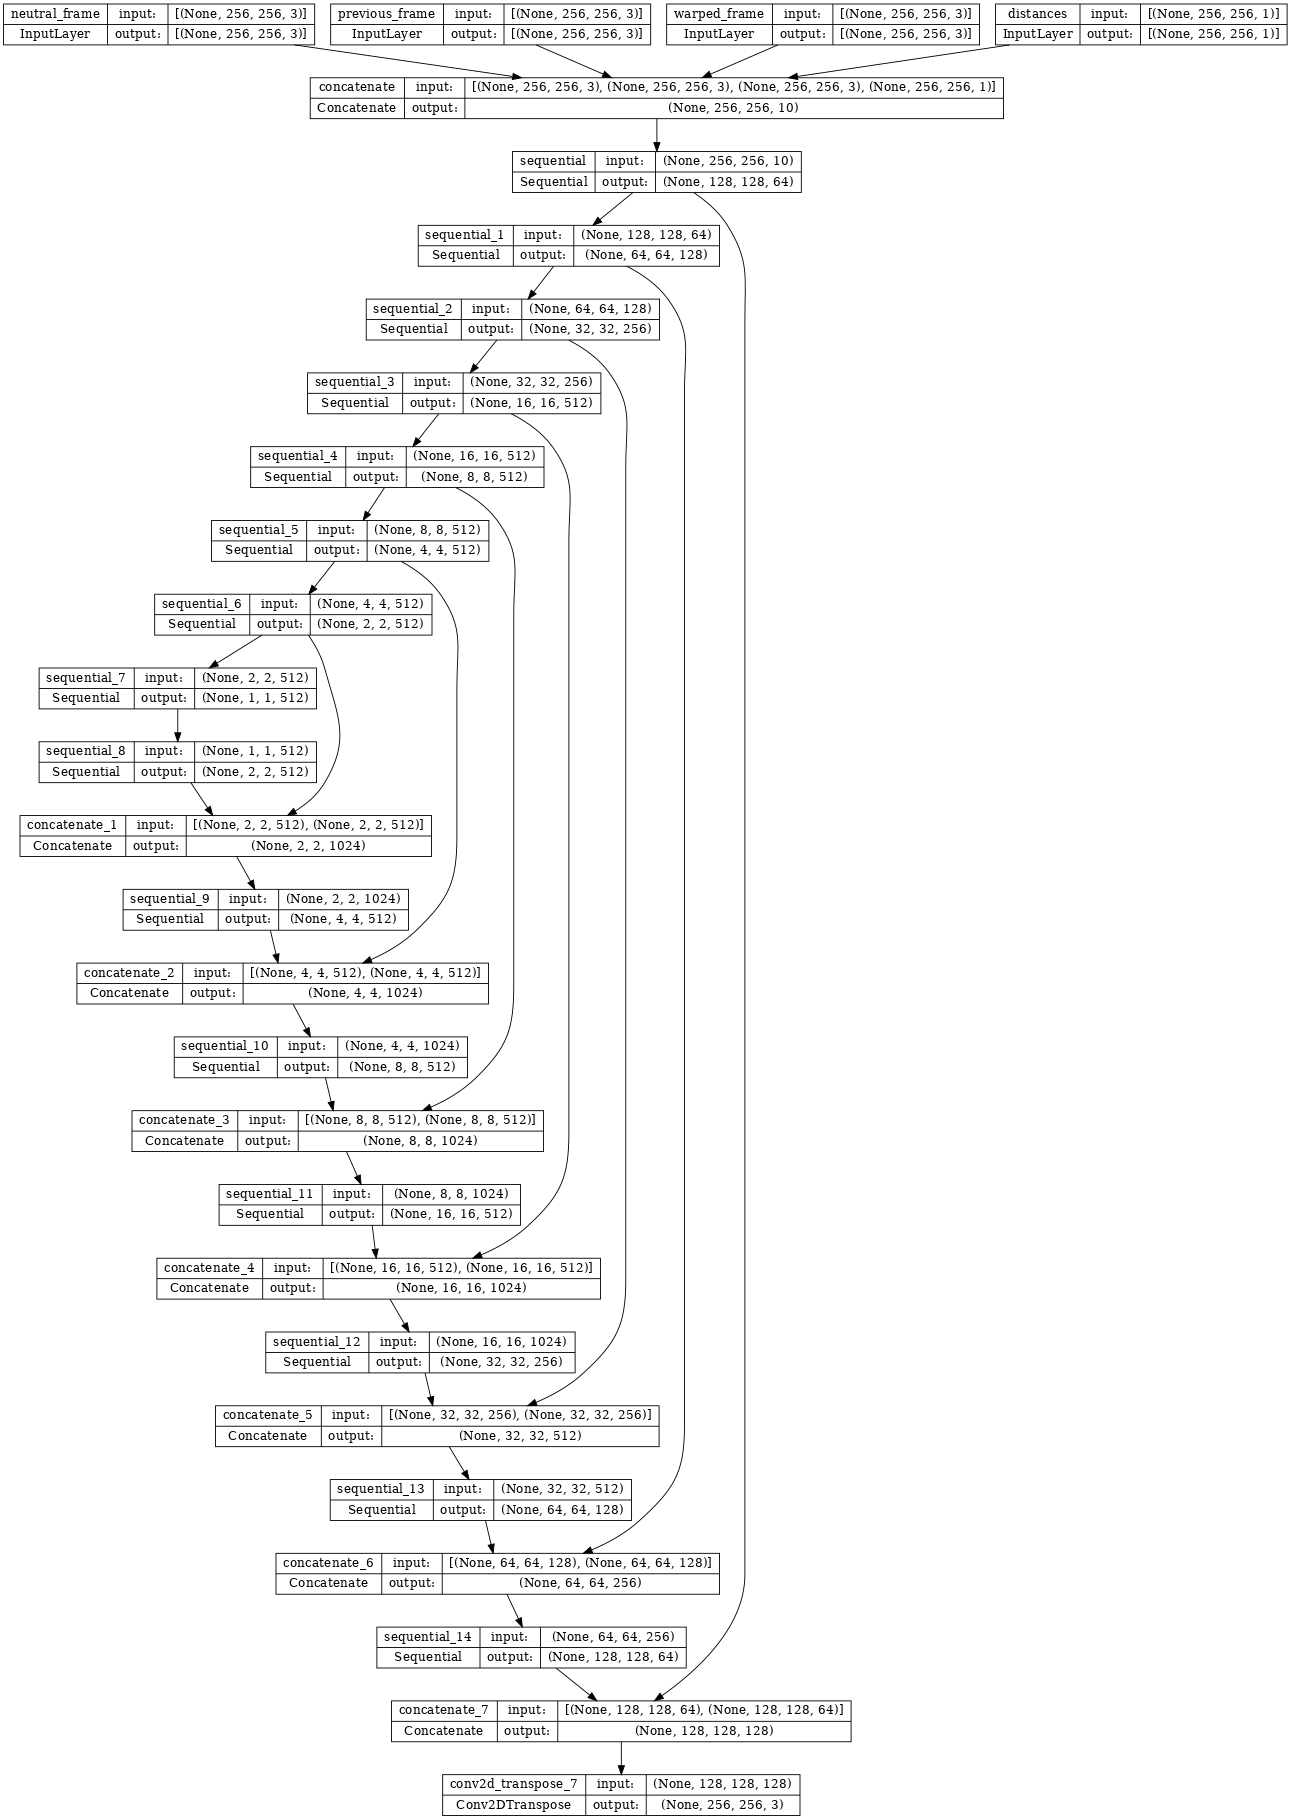

In [10]:
generator = get_generator_model(IMG_WIDTH, IMG_HEIGHT, N_CHANNELS)
tf.keras.utils.plot_model(generator, show_shapes=True, dpi=64, to_file=str(OUTPUT_MEDIA_FOLDER / 'generator.png'))

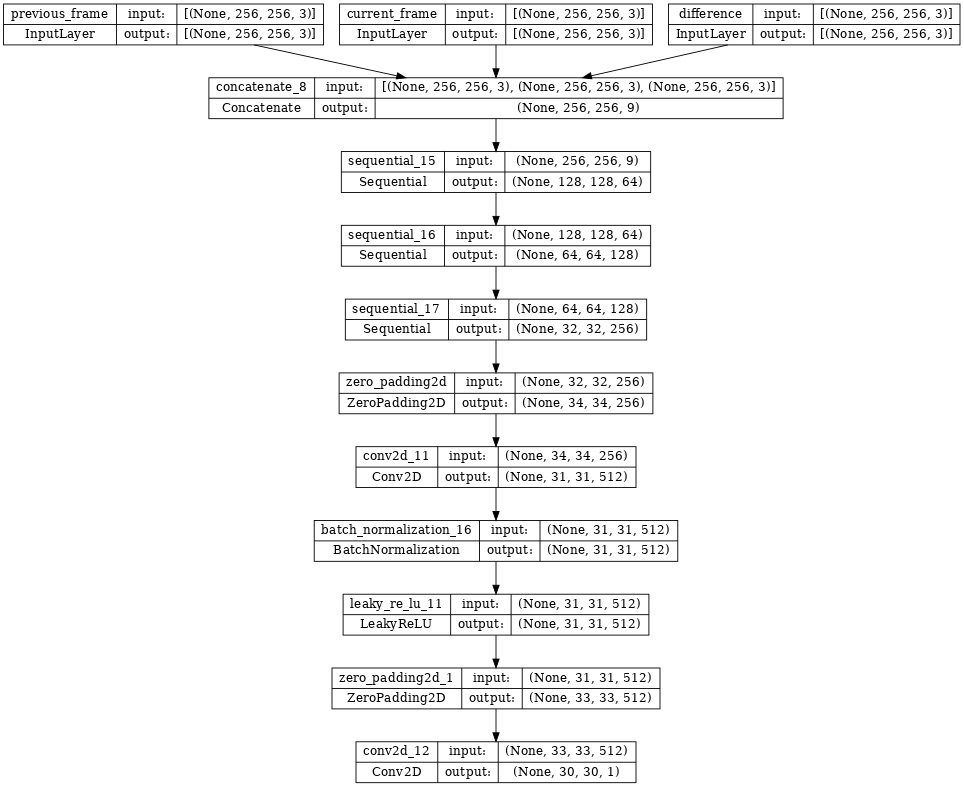

In [11]:
discriminator = get_discriminator_model(IMG_WIDTH, IMG_HEIGHT, N_CHANNELS)
tf.keras.utils.plot_model(discriminator, show_shapes=True, dpi=64, to_file=str(OUTPUT_MEDIA_FOLDER / 'discriminator.png'))

In [12]:
generator_loss = GeneratorLoss(
    # target predicted loss
    target_predicted_function=TARGET_PREDICTED_LOSS,
    lambda_target_predicted=LAMBDA_TARGET_PREDICTED_LOSS,
    # coherence loss
    coherence_loss_function=COHERENCE_LOSS,
    lambda_coherence_loss=LAMBDA_COHERENCE_LOSS,
    # landmarks loss
    landmarks_loss_function=LANDMARKS_LOSS,
    lambda_landmarks_loss=LAMBDA_LANDMARKS_LOSS,
    # landmarks coherence loss
    landmarks_coherence_loss_function=LANDMARKS_COHERENCE_LOSS,
    lambda_landmarks_coherence_loss=LAMBDA_LANDMARKS_COHERENCE_LOSS,
    # perceptual loss
    lambda_perceptual_loss=LAMBDA_PERCEPTUAL_LOSS,
    # interpolation frames loss
    interpolation_frames_loss_function=INTERPOLATION_FRAMES_LOSS,
    lambda_interpolation_frames_loss=LAMBDA_INTERPOLATION_FRAMES_LOSS,
    # interpolation landmarks loss
    interpolation_landmarks_loss_function=INTERPOLATION_LANDMARKS_LOSS,
    lambda_interpolation_landmarks_loss=LAMBDA_INTERPOLATION_LANDMARKS_LOSS
)
                    

In [13]:
discriminator_loss = DiscriminatorLoss()

In [14]:
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

In [15]:
BASE_DIR = OUPUT_PATH / id_string
checkpoint_dir = str(BASE_DIR / 'training_checkpoints')
# checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)
checkpoint_manager = tf.train.CheckpointManager(checkpoint, directory=checkpoint_dir, max_to_keep=5)

## Training


In [16]:
summary_writer = tf.summary.create_file_writer(str(log_file))

In [17]:
def fit(train_dataset_generator, test_dataset_generator, steps):
  pbar = tqdm(range(steps), total=steps)
  for step in pbar:
    with tf.profiler.experimental.Trace('train', step_num=step, _r=1):

      if (step) % DISPLAY_EACH_STEPS == 0:
        clear_output(wait=True)
        display(pbar.container)
        previously_generated, generated_frames, samples_target = test_dataset_generator.generate_first_batch()
        plot_results(samples_target, previously_generated, generated_frames)

      with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_total_loss, disc_loss, gen_losses = train_dataset_generator.next_loss()
        generator_gradients = gen_tape.gradient(gen_total_loss,
                                                generator.trainable_variables)
        discriminator_gradients = disc_tape.gradient(disc_loss,
                                                    discriminator.trainable_variables)

        generator_optimizer.apply_gradients(zip(generator_gradients,
                                                generator.trainable_variables))
        discriminator_optimizer.apply_gradients(zip(discriminator_gradients,
                                                    discriminator.trainable_variables))
        with summary_writer.as_default():
          tf.summary.scalar(f'gen_total_loss', gen_total_loss, step=step)
          tf.summary.scalar(f'disc_loss', disc_loss, step=step)
          for name, value in gen_losses.items():
            tf.summary.scalar(f'gen_{name}', value, step=step)
      
      if (step + 1) % SAVING_EACH_STEPS == 0:
          checkpoint_manager.save()

In [18]:
if TRAIN:
    tf.profiler.experimental.start(str(log_dir))
    train_generator = PreprocessedDataGenerator(train_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=True)
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)
    fit(train_generator, test_generator, steps=STEPS)
    checkpoint_manager.save()


## Restore the latest checkpoint and test the network

In [19]:
!ls {checkpoint_dir}

checkpoint		      ckpt-199.index
ckpt-197.data-00000-of-00001  ckpt-200.data-00000-of-00001
ckpt-197.index		      ckpt-200.index
ckpt-198.data-00000-of-00001  ckpt-201.data-00000-of-00001
ckpt-198.index		      ckpt-201.index
ckpt-199.data-00000-of-00001


In [20]:
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

## Generate some images using the test set

Input Sequence


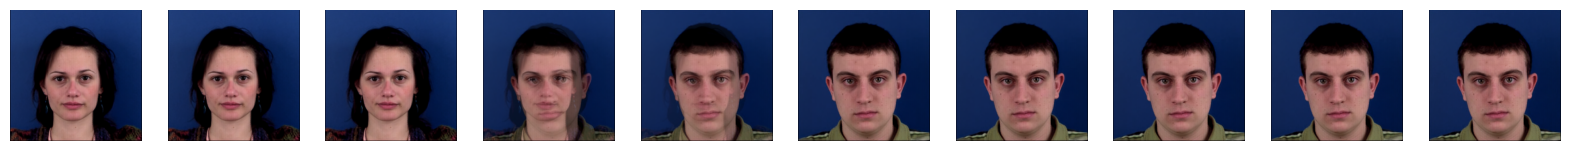

Ground Truth


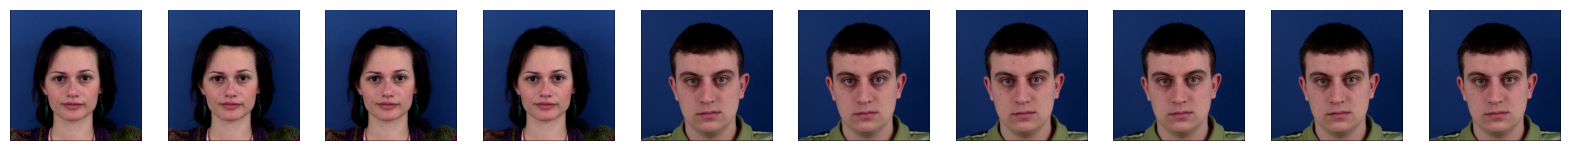

Predicted Sequence


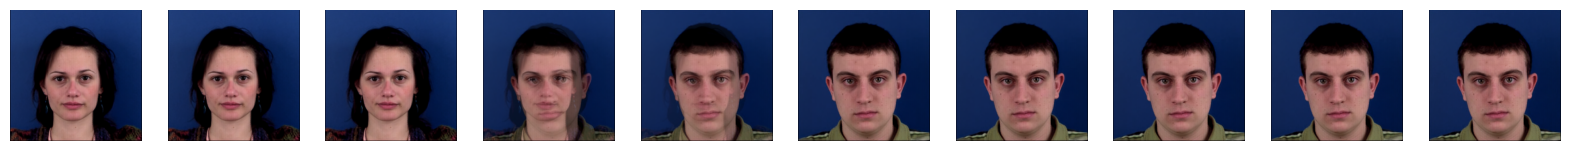

In [21]:
test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)
for i in range(0,10):
  generated_frames, samples_target = test_generator.blended_next_batch()
  clear_output(wait=True)
  plot_results(samples_target, generated_frames, generated_frames)

In [22]:
# adapted from https://gist.github.com/lukoshkin/6205455d5b931dcdbd923323003058f0 
# and https://github.com/valerystrizh/mocogan_modified/blob/0860daaa6564b563b5acc1d88f19bac051c1d1c6/src/metrics.py
def acd(frames):
    N = np.multiply.reduce(frames.shape[1:-1])
    res = np.mean(
            np.linalg.norm(
              np.diff(
                np.einsum('ijkl->il', frames), 
              axis=0) / N, 
            axis=1)
          ) 

    return res

def compare_acd(target_sequence, generated_output):
    return np.abs(acd(target_sequence) - acd(generated_output))

In [23]:
# evaluating the results with SSIM
def evaluate_metrics(normalized_target_sequence, normalized_generated_output, batch_size):
    target_sequence = images_from_normalized(normalized_target_sequence)
    generated_output = images_from_normalized(normalized_generated_output)
    #cast to float32
    normalized_target_sequence = tf.cast(normalized_target_sequence, tf.float32)
    normalized_generated_output = tf.cast(normalized_generated_output, tf.float32)
    #compute ssim
    ssim_scores = tf.image.ssim(target_sequence, generated_output, max_val=255)
    #compute psnr
    psnr_scores = tf.image.psnr(target_sequence, generated_output, max_val=255)
    #compute mse
    mse_scores = tf.keras.losses.MSE(normalized_target_sequence, normalized_generated_output)
    #compute l1
    l1_scores = tf.keras.losses.MAE(normalized_target_sequence, normalized_generated_output)
    # compute fid
    # fid_scores = get_frechet_inception_distance(target_sequence, generated_output, batch_size=batch_size, num_inception_images=batch_size) # TODO: pre frame
    # compute fvd
    # fvd_scores = calculate_fvd(target_sequence, generated_output)
    # compute acd
    acd_scores = compare_acd(target_sequence, generated_output) # TODO: per video
    return  {
        "SSIM": tf.reduce_mean(ssim_scores).numpy(),
        "PSNR": tf.reduce_mean(psnr_scores).numpy(),
        "MSE": tf.reduce_mean(mse_scores).numpy(),
        "L1": tf.reduce_mean(l1_scores).numpy(),
        # "FVD": fvd_scores
        # "FID": fid_scores.numpy(),
        "ACD": acd_scores
    }

def compute_scores():
    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                display(pbar.container)
                df = pd.DataFrame(scores)
                df.to_csv(f"{log_dir}/metrics.csv")
                print(df.mean())
                print(df.std())
                generated_frames, current_frames = test_generator.blended_next_batch()
                s = evaluate_metrics(current_frames, generated_frames, batch_size=BATCH_SIZE)
                scores.append(s)
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break
    return scores

In [24]:
if TEST:
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)
    scores_path = f"{log_dir}/metrics.csv"
    # df = pd.read_csv(scores_path, index_col=0)  
    scores = compute_scores()
    df = pd.DataFrame(scores)
    df.to_csv(scores_path)

42060it [1:08:19,  2.39it/s]

SSIM     0.914929
PSNR    35.158245
MSE      0.001590
L1       0.022884
ACD      0.000412
dtype: float64
SSIM    0.038874
PSNR    2.157655
MSE     0.001498
L1      0.007887
ACD     0.000307
dtype: float64


In [25]:
if TEST:
    print(df)

          SSIM       PSNR       MSE        L1       ACD
0     0.923145  35.388035  0.001111  0.019654  0.000474
1     0.919706  35.142967  0.001169  0.020108  0.000004
2     0.920161  35.161903  0.001162  0.020210  0.000060
3     0.919185  35.110394  0.001179  0.020278  0.000870
4     0.918945  35.363289  0.001107  0.019758  0.000321
...        ...        ...       ...       ...       ...
4201  0.901342  34.181622  0.001451  0.025586  0.000330
4202  0.876868  32.614429  0.005713  0.037562  0.000471
4203  0.906411  35.320698  0.001112  0.023139  0.000657
4204  0.905965  35.465218  0.001074  0.022931  0.000112
4205  0.885532  32.471893  0.008076  0.043434  0.000805

[4206 rows x 5 columns]


In [26]:
if TEST:
    print(df.mean())

SSIM     0.914929
PSNR    35.158245
MSE      0.001590
L1       0.022884
ACD      0.000412
dtype: float64


In [27]:
if TEST:
    print(df.std())

SSIM    0.038874
PSNR    2.157655
MSE     0.001498
L1      0.007887
ACD     0.000307
dtype: float64


# coherence measures

In [28]:
def compute_scores_diff():
    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                display(pbar.container)
                df = pd.DataFrame(scores)
                df.to_csv(f"{log_dir}/diff_metrics.csv")
                print(df.mean())
                print(df.std())
                _, generated_frames, current_frames = test_generator.blended_diff_batch()
                s = evaluate_metrics(current_frames, generated_frames, batch_size=BATCH_SIZE)
                scores.append(s)
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break
    return scores

if TEST:
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)
    scores_path = f"{log_dir}/diff_metrics.csv"
    # df = pd.read_csv(scores_path, index_col=0)  
    scores = compute_scores_diff()
    df = pd.DataFrame(scores)
    df.to_csv(scores_path)

42060it [1:17:12,  2.39it/s]

SSIM     0.958320
PSNR    42.876488
MSE      0.000672
L1       0.009402
ACD      0.000404
dtype: float64
SSIM    0.024127
PSNR    3.469244
MSE     0.001557
L1      0.006827
ACD     0.000310
dtype: float64


In [29]:
if TEST:
    print(df.mean())

SSIM     0.958320
PSNR    42.876488
MSE      0.000672
L1       0.009402
ACD      0.000404
dtype: float64


In [30]:
if TEST:
    print(df.std())

SSIM    0.024127
PSNR    3.469244
MSE     0.001557
L1      0.006827
ACD     0.000310
dtype: float64


# Plot some images

In [31]:
if PLOT:
  test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)
  for i in range(0,10):
    clear_output(wait=True)
    test_generator.next_plot()

# Save videos gifs

In [32]:
from data_generator import PreprocessedDataGenerator
if SAVE_GIFS:
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, save_path=OUTPUT_MEDIA_FOLDER)
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                test_generator.save_next_video()
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break

KeyboardInterrupt: 

# Test per video

In [ ]:
def compute_scores_video():
    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                display(pbar.container)
                df = pd.DataFrame(scores)
                df.to_csv(f"{log_dir}/video_metrics.csv")
                if "path_id" in df.columns:
                    print(df.drop(columns=["path_id"], inplace=False).mean())
                    print(df.drop(columns=["path_id"], inplace=False).std())
                current_frames, generated_frames, path_id = test_generator.generate_next_video() # TODO: blended frames
                if current_frames is not None and generated_frames is not None:
                    video_size = generated_frames.shape[1]
                    s = evaluate_metrics(current_frames, generated_frames, batch_size=video_size)
                    s["path_id"] = path_id
                    scores.append(s)
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break
    return scores

In [ ]:
if TEST_VIDEO:
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)
    scores_path = f"{log_dir}/video_metrics.csv"
    # df = pd.read_csv(scores_path, index_col=0)  
    scores = compute_scores_video()
    df = pd.DataFrame(scores)
    df.to_csv(scores_path)

In [ ]:
if TEST_VIDEO:
    print(df.drop(columns=["path_id"], inplace=False).mean())

In [ ]:
if TEST_VIDEO:
    print(df.drop(columns=["path_id"], inplace=False).std())

In [ ]:
def compute_video_scores_diff():
    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                display(pbar.container)
                df = pd.DataFrame(scores)
                df.to_csv(f"{log_dir}/video_diff_metrics.csv")
                if "path_id" in df.columns:
                    print(df.drop(columns=["path_id"], inplace=False).mean())
                    print(df.drop(columns=["path_id"], inplace=False).std())
                current_frames, generated_frames, path_id = test_generator.generate_diff_video() # TODO: blended frames
                if current_frames is not None and generated_frames is not None:
                    video_size = generated_frames.shape[1]
                    s = evaluate_metrics(current_frames, generated_frames, batch_size=video_size)
                    s["path_id"] = path_id
                    scores.append(s)
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break
    return scores

if TEST_VIDEO:
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)
    scores_path = f"{log_dir}/video_diff_metrics.csv"
    # df = pd.read_csv(scores_path, index_col=0)  
    scores = compute_video_scores_diff()
    df = pd.DataFrame(scores)
    df.to_csv(scores_path)

In [ ]:
if TEST_VIDEO:
    print(df.drop(columns=["path_id"], inplace=False).mean())

In [ ]:
if TEST_VIDEO:
    print(df.drop(columns=["path_id"], inplace=False).std())

# Test deformation

In [ ]:
def compute_deformation_scores():
    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                display(pbar.container)
                df = pd.DataFrame(scores)
                df.to_csv(f"{log_dir}/deformed_metrics.csv")
                print(df.mean())
                print(df.std())
                deformed_frames, current_frames = test_generator.deformed_next_batch()
                s = evaluate_metrics(current_frames, deformed_frames, batch_size=BATCH_SIZE)
                scores.append(s)
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break
    return scores

if TEST_DEFORMATIONS:
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)
    scores_path = f"{log_dir}/deformed_metrics.csv"
    # df = pd.read_csv(scores_path, index_col=0)  
    scores = compute_deformation_scores()
    df = pd.DataFrame(scores)
    df.to_csv(scores_path)

In [ ]:
if TEST_DEFORMATIONS:
    print(df.mean())

In [ ]:
if TEST_DEFORMATIONS:
    print(df.std())

In [ ]:
def compute_scores_deformed_diff():
    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                display(pbar.container)
                df = pd.DataFrame(scores)
                df.to_csv(f"{log_dir}/deformed_diff_metrics.csv")
                print(df.mean())
                print(df.std())
                current_diffs, deformed_diffs = test_generator.get_deformed_diff_batch()
                s = evaluate_metrics(current_diffs, deformed_diffs, batch_size=BATCH_SIZE)
                scores.append(s)
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break
    return scores

if TEST_DEFORMATIONS:
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)
    scores_path = f"{log_dir}/deformed_diff_metrics.csv"
    # df = pd.read_csv(scores_path, index_col=0)  
    scores = compute_scores_deformed_diff()
    df = pd.DataFrame(scores)
    df.to_csv(scores_path)

In [ ]:
if TEST_DEFORMATIONS:
    print(df.mean())

In [ ]:
if TEST_DEFORMATIONS:
    print(df.std())

# Test blended deformations

In [ ]:
def compute_deformation_scores():
    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                display(pbar.container)
                df = pd.DataFrame(scores)
                df.to_csv(f"{log_dir}/blended_deformations_metrics.csv")
                print(df.mean())
                print(df.std())
                deformed_frames, current_frames = test_generator.deformed_next_batch()
                s = evaluate_metrics(current_frames, deformed_frames, batch_size=BATCH_SIZE)
                scores.append(s)
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break
    return scores

if TEST_DEFORMATIONS:
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)
    scores_path = f"{log_dir}/blended_deformations_metrics.csv"
    # df = pd.read_csv(scores_path, index_col=0)  
    scores = compute_deformation_scores()
    df = pd.DataFrame(scores)
    df.to_csv(scores_path)

In [ ]:
if TEST_DEFORMATIONS:
    print(df.mean())

In [ ]:
if TEST_DEFORMATIONS:
    print(df.std())

In [ ]:
def compute_scores_deformed_diff():
    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                display(pbar.container)
                df = pd.DataFrame(scores)
                df.to_csv(f"{log_dir}/blended_deformations_diff_metrics.csv")
                print(df.mean())
                print(df.std())
                current_diffs, deformed_diffs = test_generator.get_deformed_diff_batch()
                s = evaluate_metrics(current_diffs, deformed_diffs, batch_size=BATCH_SIZE)
                scores.append(s)
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break
    return scores

if TEST_DEFORMATIONS:
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, blend_deformation=True)
    scores_path = f"{log_dir}/blended_deformations_diff_metrics.csv"
    # df = pd.read_csv(scores_path, index_col=0)  
    scores = compute_scores_deformed_diff()
    df = pd.DataFrame(scores)
    df.to_csv(scores_path)

In [ ]:
if TEST_DEFORMATIONS:
    print(df.mean())

In [ ]:
if TEST_DEFORMATIONS:
    print(df.std())